# Sen1Floods11 — exploratory look

Goals of this notebook (week 1 of `docs/PLAN.md`):

1. Confirm chip counts per split and the label value set.
2. Look at a handful of chips: RGB, false-colour SWIR composite, Sentinel-1 VV, hand label.
3. Water fraction per chip, per split, per region (class imbalance, Bolivia vs rest).
4. Per-band statistics sanity check against `configs/data/stats.yaml`.


In [1]:
import collections
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

ROOT = Path("..") / "data" / "sen1floods11"
sys.path.insert(0, str(Path("..") / "src"))
from eoflood.data import S2_BANDS, Sen1Floods11, read_split
from eoflood.metrics import IGNORE_INDEX

splits = {s: read_split(ROOT, s) for s in ("train", "valid", "test", "bolivia")}
{s: len(v) for s, v in splits.items()}

{'train': 252, 'valid': 89, 'test': 90, 'bolivia': 15}

## Regions per split
Each chip name starts with the flood event / country. Bolivia should appear **only** in the `bolivia` split.

In [2]:
for s, items in splits.items():
    c = collections.Counter(n.split("_")[0] for n, _ in items)
    print(f"{s:8s} {len(items):3d}  ", dict(sorted(c.items())))

train    252   {'Ghana': 31, 'India': 40, 'Mekong': 18, 'Nigeria': 10, 'Pakistan': 16, 'Paraguay': 39, 'Somalia': 15, 'Spain': 18, 'Sri-Lanka': 24, 'USA': 41}
valid     89   {'Ghana': 11, 'India': 14, 'Mekong': 6, 'Nigeria': 4, 'Pakistan': 6, 'Paraguay': 14, 'Somalia': 5, 'Spain': 6, 'Sri-Lanka': 9, 'USA': 14}
test      90   {'Ghana': 11, 'India': 14, 'Mekong': 6, 'Nigeria': 4, 'Pakistan': 6, 'Paraguay': 14, 'Somalia': 6, 'Spain': 6, 'Sri-Lanka': 9, 'USA': 14}
bolivia   15   {'Bolivia': 15}


## A few chips
RGB = B4/B3/B2, SWIR composite = B12/B8A/B4 (water is dark, vegetation green), S1 VV in dB, label (black = no water, white = water, red = no data).

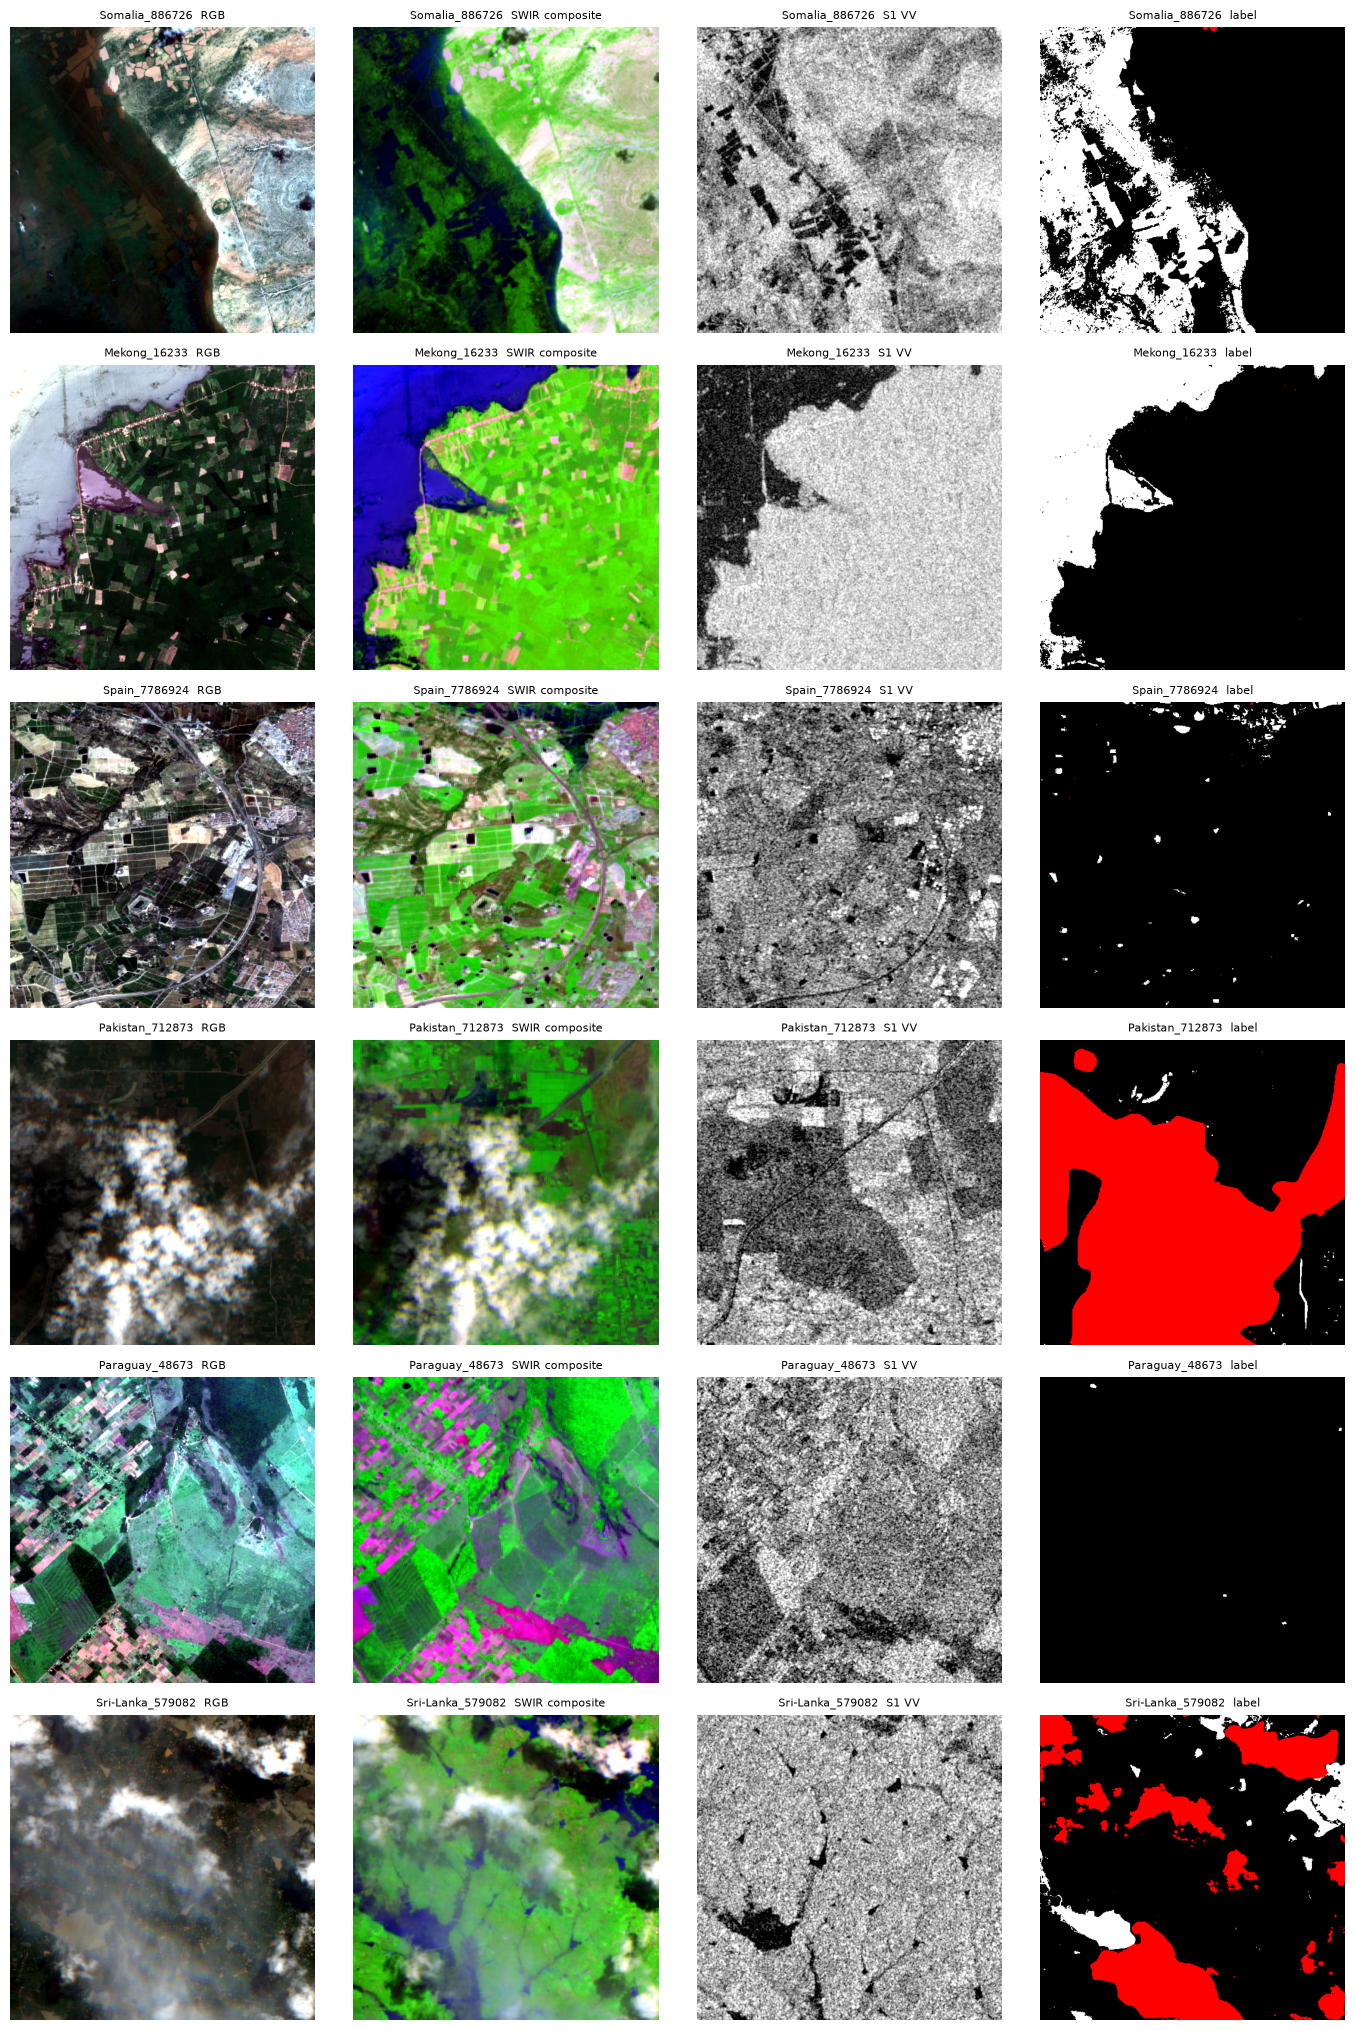

In [3]:
ds_all = Sen1Floods11(ROOT, "train", bands=S2_BANDS, use_s1=True)   # raw, unnormalized

def stretch(a, lo=2, hi=98):
    lo_v, hi_v = np.percentile(a, [lo, hi])
    return np.clip((a - lo_v) / max(hi_v - lo_v, 1e-6), 0, 1)

def show_chip(i, axes):
    x, y = ds_all.load_raw(i)
    b = {name: x[k] for k, name in enumerate(S2_BANDS)}
    vv = x[len(S2_BANDS)]
    rgb = np.dstack([stretch(b["B4"]), stretch(b["B3"]), stretch(b["B2"])])
    swir = np.dstack([stretch(b["B12"]), stretch(b["B8A"]), stretch(b["B4"])])
    lab = np.zeros((*y.shape, 3)); lab[y == 1] = 1; lab[y == IGNORE_INDEX] = (1, 0, 0)
    for ax, img, t in zip(axes, [rgb, swir, stretch(vv), lab], ["RGB", "SWIR composite", "S1 VV", "label"]):
        ax.imshow(img, cmap=None if img.ndim == 3 else "gray"); ax.set_title(f"{ds_all.items[i][0].split('_S1')[0]}  {t}", fontsize=8); ax.axis("off")

rng = np.random.RandomState(0)
idx = rng.choice(len(ds_all), 6, replace=False)
fig, axes = plt.subplots(len(idx), 4, figsize=(14, 3.4 * len(idx)))
for row, i in zip(axes, idx):
    show_chip(i, row)
plt.tight_layout()

## Water fraction per chip
Fraction of *valid* pixels labelled water. Also how much of each chip is no-data (`-1`).

split              bolivia    test    train   valid
water_frac  count   15.000  89.000  251.000  86.000
            mean     0.170   0.135    0.094   0.114
            std      0.212   0.239    0.173   0.181
            min      0.000   0.000    0.000   0.000
            25%      0.024   0.008    0.004   0.006
            50%      0.063   0.025    0.025   0.025
            75%      0.279   0.112    0.102   0.166
            max      0.659   1.000    0.974   0.923
nodata_frac count   15.000  90.000  252.000  89.000
            mean     0.271   0.130    0.133   0.130
            std      0.191   0.229    0.219   0.226
            min      0.000   0.000    0.000   0.000
            25%      0.147   0.000    0.000   0.000
            50%      0.272   0.002    0.009   0.002
            75%      0.399   0.165    0.188   0.170
            max      0.664   1.000    1.000   1.000


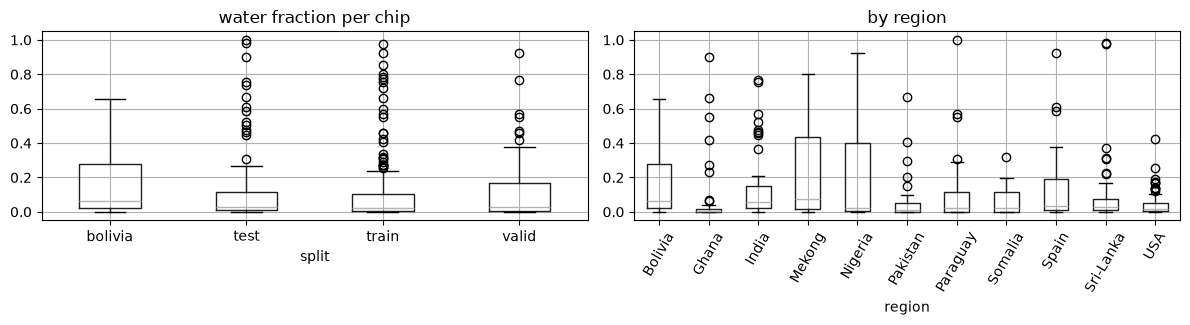

In [4]:
rows = []
for s in splits:
    ds = Sen1Floods11(ROOT, s, bands=["B2"])
    for i in range(len(ds)):
        _, y = ds.load_raw(i)
        valid = y != IGNORE_INDEX
        rows.append((s, ds.items[i][0].split("_")[0], (y[valid] == 1).mean() if valid.any() else np.nan, 1 - valid.mean()))
import pandas as pd

df = pd.DataFrame(rows, columns=["split", "region", "water_frac", "nodata_frac"])
print(df.groupby("split")[["water_frac", "nodata_frac"]].describe().round(3).T)
fig, ax = plt.subplots(1, 2, figsize=(12, 3.5))
df.boxplot(column="water_frac", by="split", ax=ax[0]); ax[0].set_title("water fraction per chip")
df.boxplot(column="water_frac", by="region", ax=ax[1], rot=60); ax[1].set_title("by region")
plt.suptitle(""); plt.tight_layout()

## Band statistics
Compare with `configs/data/stats.yaml` (written by `scripts/compute_stats.py`). Reflectance ×10 000: means of a few hundred to a few thousand are expected.

In [5]:
stats_path = Path("..") / "configs" / "data" / "stats.yaml"
if stats_path.exists():
    st = yaml.safe_load(stats_path.read_text())
    print(pd.DataFrame({"band": st["bands"], "mean": st["mean"], "std": st["std"]}).to_string(index=False))
else:
    print("run scripts/compute_stats.py first")

band      mean       std
  B2 1396.0347  739.0945
  B3 1364.0612  735.2482
  B4 1218.2285  864.9367
 B8A 3077.4822 1196.4426
 B11 2030.6476  980.8706
 B12 1179.1661  764.6084


## Notes

- Fill in after running: anything surprising about no-data, cloud-heavy chips, regions with almost no water, Bolivia vs the rest.
- Copy the key numbers (chip counts, median water fraction, nodata share) into `docs/LAB_NOTEBOOK.md`.
